In [ ]:
from google.colab import files
uploaded = files.upload()

Saving bank-full.csv to bank-full.csv


In [ ]:
import pandas as pd

df = pd.read_csv("bank-full.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


##Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

print("Essential libraries imported successfully.")

Essential libraries imported successfully.


## Load Dataset



In [ ]:
print("First 5 rows of the DataFrame:")
print(df.head())
print("\nShape of the DataFrame:")
print(df.shape)

First 5 rows of the DataFrame:
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  

Shape of the DataFrame:
(45211, 17)


## Data Preprocessing




In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# 'y' is the target variable
target_col = 'y'
categorical_cols.remove(target_col)

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)
print("Target column:", target_col)

Numerical columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Target column: y


In [ ]:
label_encoder = LabelEncoder()
df['y_encoded'] = label_encoder.fit_transform(df[target_col])

print("Original 'y' value counts:")
print(df[target_col].value_counts())
print("\nEncoded 'y' value counts:")
print(df['y_encoded'].value_counts())


Original 'y' value counts:
y
no     39922
yes     5289
Name: count, dtype: int64

Encoded 'y' value counts:
y_encoded
0    39922
1     5289
Name: count, dtype: int64


In [ ]:
onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
categorical_encoded = onehot_encoder.fit_transform(df[categorical_cols])
categorical_encoded_df = pd.DataFrame(categorical_encoded, columns=onehot_encoder.get_feature_names_out(categorical_cols))

print("Shape of one-hot encoded categorical DataFrame:", categorical_encoded_df.shape)
print("First 5 rows of one-hot encoded categorical DataFrame:")
print(categorical_encoded_df.head())

Shape of one-hot encoded categorical DataFrame: (45211, 44)
First 5 rows of one-hot encoded categorical DataFrame:
   job_admin.  job_blue-collar  job_entrepreneur  job_housemaid  \
0         0.0              0.0               0.0            0.0   
1         0.0              0.0               0.0            0.0   
2         0.0              0.0               1.0            0.0   
3         0.0              1.0               0.0            0.0   
4         0.0              0.0               0.0            0.0   

   job_management  job_retired  job_self-employed  job_services  job_student  \
0             1.0          0.0                0.0           0.0          0.0   
1             0.0          0.0                0.0           0.0          0.0   
2             0.0          0.0                0.0           0.0          0.0   
3             0.0          0.0                0.0           0.0          0.0   
4             0.0          0.0                0.0           0.0          0.0   

 

In [ ]:
scaler = StandardScaler()
numerical_scaled = scaler.fit_transform(df[numerical_cols])
numerical_scaled_df = pd.DataFrame(numerical_scaled, columns=numerical_cols)

print("Shape of scaled numerical DataFrame:", numerical_scaled_df.shape)
print("First 5 rows of scaled numerical DataFrame:")
print(numerical_scaled_df.head())

Shape of scaled numerical DataFrame: (45211, 7)
First 5 rows of scaled numerical DataFrame:
        age   balance       day  duration  campaign     pdays  previous
0  1.606965  0.256419 -1.298476  0.011016 -0.569351 -0.411453  -0.25194
1  0.288529 -0.437895 -1.298476 -0.416127 -0.569351 -0.411453  -0.25194
2 -0.747384 -0.446762 -1.298476 -0.707361 -0.569351 -0.411453  -0.25194
3  0.571051  0.047205 -1.298476 -0.645231 -0.569351 -0.411453  -0.25194
4 -0.747384 -0.447091 -1.298476 -0.233620 -0.569351 -0.411453  -0.25194


In [ ]:
X = pd.concat([numerical_scaled_df, categorical_encoded_df], axis=1)
y = df['y_encoded']

print("Shape of the preprocessed feature DataFrame (X):", X.shape)
print("Shape of the target variable (y):", y.shape)
print("First 5 rows of the preprocessed feature DataFrame (X):")
print(X.head())

Shape of the preprocessed feature DataFrame (X): (45211, 51)
Shape of the target variable (y): (45211,)
First 5 rows of the preprocessed feature DataFrame (X):
        age   balance       day  duration  campaign     pdays  previous  \
0  1.606965  0.256419 -1.298476  0.011016 -0.569351 -0.411453  -0.25194   
1  0.288529 -0.437895 -1.298476 -0.416127 -0.569351 -0.411453  -0.25194   
2 -0.747384 -0.446762 -1.298476 -0.707361 -0.569351 -0.411453  -0.25194   
3  0.571051  0.047205 -1.298476 -0.645231 -0.569351 -0.411453  -0.25194   
4 -0.747384 -0.447091 -1.298476 -0.233620 -0.569351 -0.411453  -0.25194   

   job_admin.  job_blue-collar  job_entrepreneur  ...  month_jun  month_mar  \
0         0.0              0.0               0.0  ...        0.0        0.0   
1         0.0              0.0               0.0  ...        0.0        0.0   
2         0.0              0.0               1.0  ...        0.0        0.0   
3         0.0              1.0               0.0  ...        0.0        0

## Unsupervised Learning (K-Means)




In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X)

# Create a temporary DataFrame for plotting with original scaled 'age' and 'balance' and new cluster labels
plot_df = X[['age', 'balance']].copy()
plot_df['cluster'] = clusters

print("First 5 rows of the DataFrame with clusters:")
print(plot_df.head())
print("\nCluster value counts:")
print(plot_df['cluster'].value_counts())

First 5 rows of the DataFrame with clusters:
        age   balance  cluster
0  1.606965  0.256419        2
1  0.288529 -0.437895        0
2 -0.747384 -0.446762        0
3  0.571051  0.047205        0
4 -0.747384 -0.447091        0

Cluster value counts:
cluster
0    22849
2    15303
1     7059
Name: count, dtype: int64


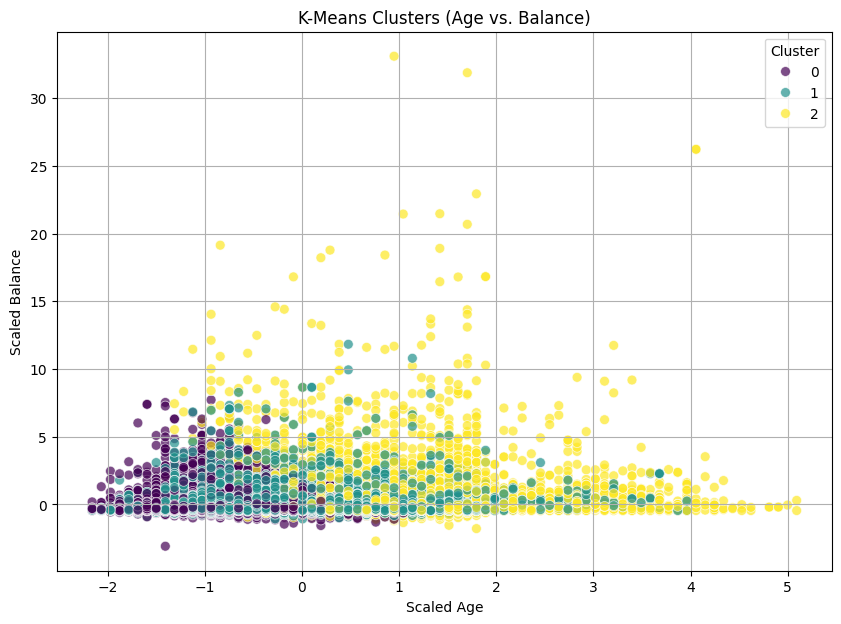

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df, x='age', y='balance', hue='cluster', palette='viridis', s=50, alpha=0.7)
plt.title('K-Means Clusters (Age vs. Balance)')
plt.xlabel('Scaled Age')
plt.ylabel('Scaled Balance')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


## Prepare Data for Supervised Learning



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (36168, 51)
Shape of X_test: (9043, 51)
Shape of y_train: (36168,)
Shape of y_test: (9043,)


## Logistic Regression Model




Logistic Regression Accuracy: 0.9015
Logistic Regression Precision: 0.6462
Logistic Regression Recall: 0.3488


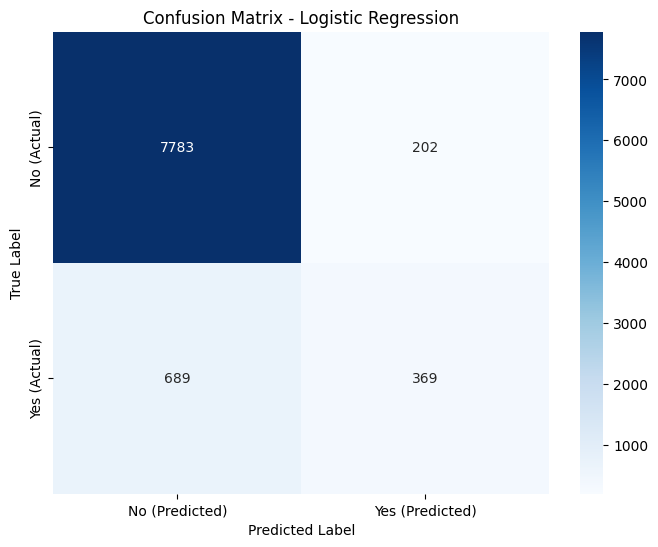

In [ ]:
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
log_reg_model.fit(X_train, y_train)
y_pred_lr = log_reg_model.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)

print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")
print(f"Logistic Regression Precision: {precision_lr:.4f}")
print(f"Logistic Regression Recall: {recall_lr:.4f}")

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No (Predicted)', 'Yes (Predicted)'],
            yticklabels=['No (Actual)', 'Yes (Actual)'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Decision Tree Model



In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)

print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")
print(f"Decision Tree Precision: {precision_dt:.4f}")
print(f"Decision Tree Recall: {recall_dt:.4f}")

Decision Tree Accuracy: 0.8749
Decision Tree Precision: 0.4662
Decision Tree Recall: 0.4764


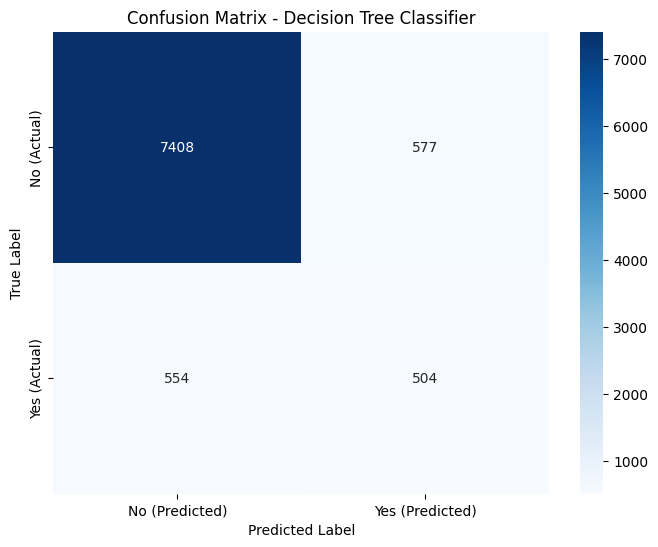

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No (Predicted)', 'Yes (Predicted)'],
            yticklabels=['No (Actual)', 'Yes (Actual)'])
plt.title('Confusion Matrix - Decision Tree Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## K-Nearest Neighbors Model



In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)

print(f"K-Nearest Neighbors Accuracy: {accuracy_knn:.4f}")
print(f"K-Nearest Neighbors Precision: {precision_knn:.4f}")
print(f"K-Nearest Neighbors Recall: {recall_knn:.4f}")

K-Nearest Neighbors Accuracy: 0.8963
K-Nearest Neighbors Precision: 0.6007
K-Nearest Neighbors Recall: 0.3384


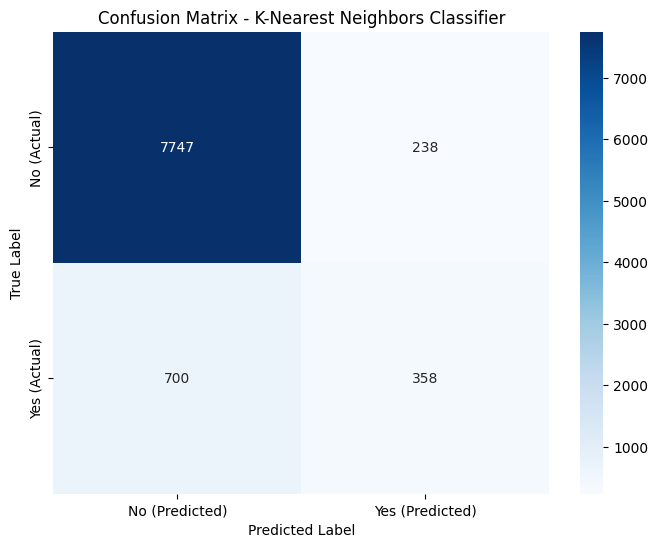

In [ ]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No (Predicted)', 'Yes (Predicted)'],
            yticklabels=['No (Actual)', 'Yes (Actual)'])
plt.title('Confusion Matrix - K-Nearest Neighbors Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Compare Models



In [ ]:
print(f"\n--- Model Comparison ---")
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")
print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")
print(f"K-Nearest Neighbors Accuracy: {accuracy_knn:.4f}")

# Compare accuracies
best_accuracy = max(accuracy_lr, accuracy_dt, accuracy_knn)

if best_accuracy == accuracy_lr:
    best_model = "Logistic Regression"
elif best_accuracy == accuracy_dt:
    best_model = "Decision Tree"
else:
    best_model = "K-Nearest Neighbors"

print(f"\nThe model with the highest accuracy is: {best_model} ({best_accuracy:.4f})")


--- Model Comparison ---
Logistic Regression Accuracy: 0.9015
Decision Tree Accuracy: 0.8749
K-Nearest Neighbors Accuracy: 0.8963

The model with the highest accuracy is: Logistic Regression (0.9015)


## Visualizations




In [ ]:
feature_importances = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Decision Tree Feature Importances (Top 10):\n", feature_importances.head(10))

Decision Tree Feature Importances (Top 10):
 duration            0.273015
balance             0.103257
poutcome_success    0.091396
age                 0.087124
day                 0.084717
pdays               0.044770
campaign            0.031689
housing_no          0.021358
month_mar           0.014280
month_jun           0.013520
dtype: float64


/tmp/ipykernel_164/3782441584.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.head(15).values, y=feature_importances.head(15).index, palette='viridis')


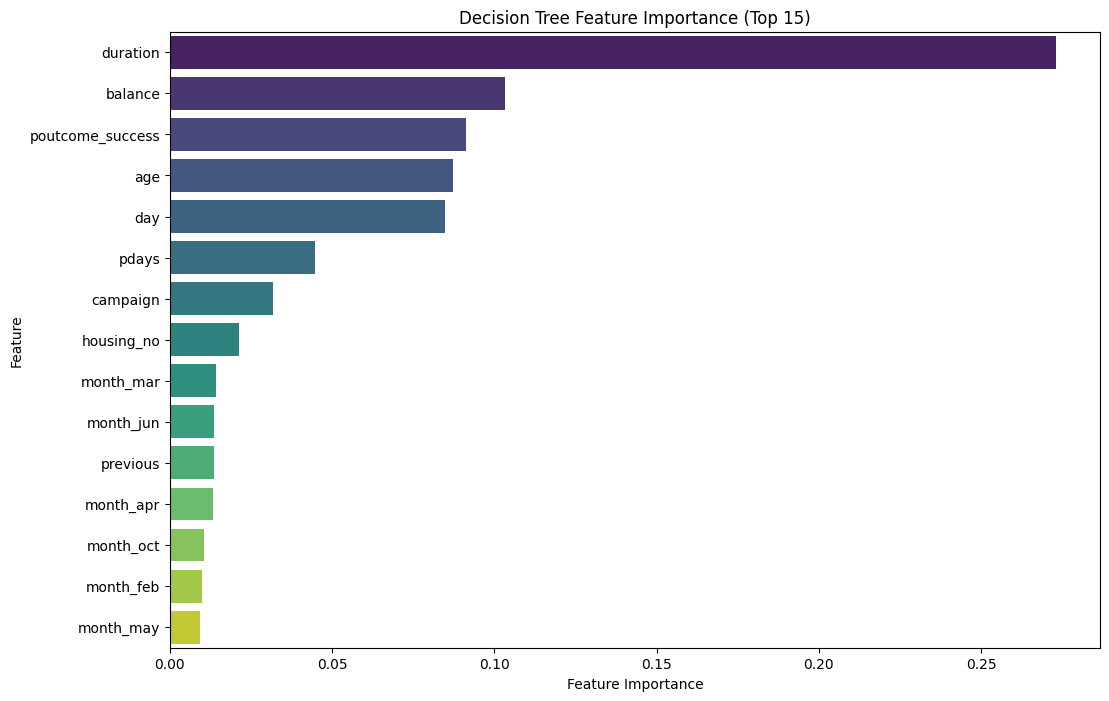

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances.head(15).values, y=feature_importances.head(15).index, palette='viridis')
plt.title('Decision Tree Feature Importance (Top 15)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.show()

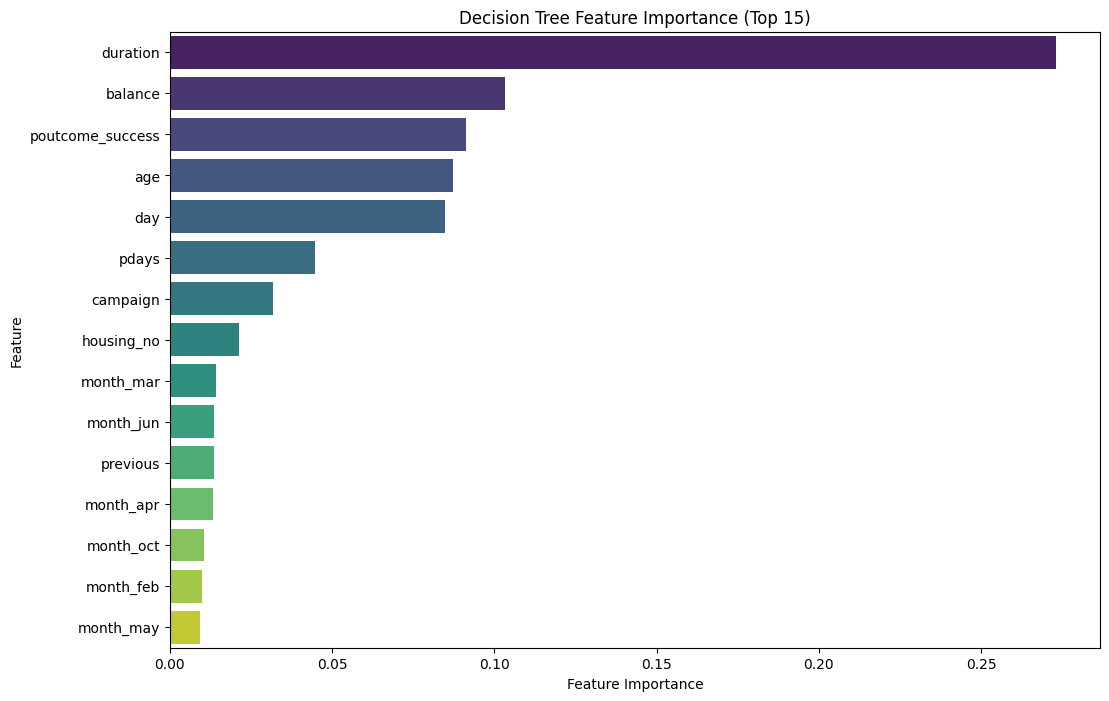

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances.head(15).values, y=feature_importances.head(15).index, hue=feature_importances.head(15).index, palette='viridis', legend=False)
plt.title('Decision Tree Feature Importance (Top 15)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.show()

In [ ]:
model_accuracies = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'K-Nearest Neighbors'],
    'Accuracy': [accuracy_lr, accuracy_dt, accuracy_knn]
})

print("Model Accuracies:")
print(model_accuracies)

Model Accuracies:
                 Model  Accuracy
0  Logistic Regression  0.901471
1        Decision Tree  0.874931
2  K-Nearest Neighbors  0.896273


/tmp/ipykernel_164/785670323.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=model_accuracies, palette='viridis')


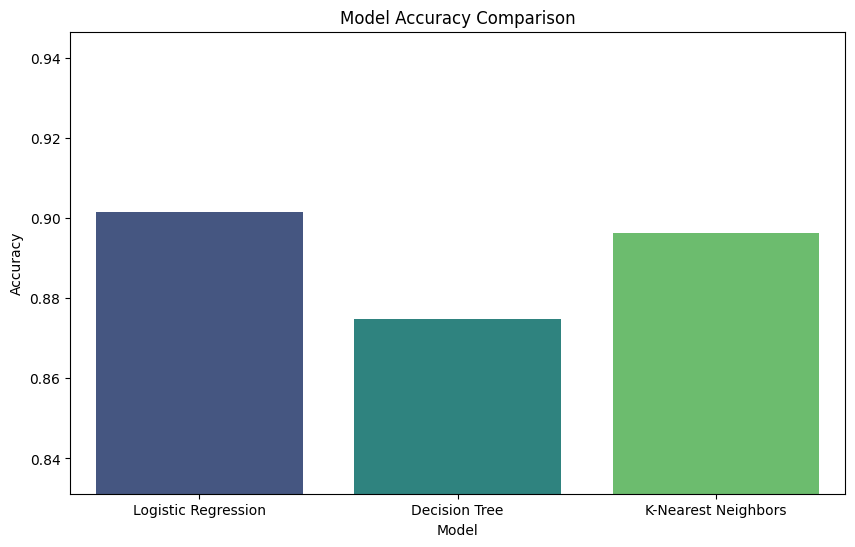

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=model_accuracies, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(min(model_accuracies['Accuracy']) * 0.95, max(model_accuracies['Accuracy']) * 1.05) # Adjust y-axis for better visibility
plt.show()

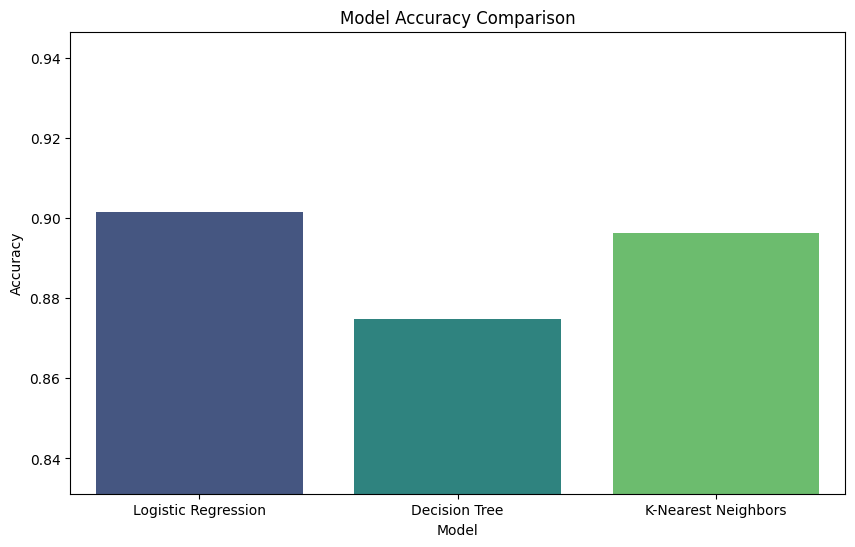

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=model_accuracies, hue='Model', palette='viridis', legend=False)
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(min(model_accuracies['Accuracy']) * 0.95, max(model_accuracies['Accuracy']) * 1.05) # Adjust y-axis for better visibility
plt.show()

## Print Insights




In [ ]:
print("--- Insights Summary ---")
print(f"1. The best-performing supervised learning model based on accuracy is {best_model} with an accuracy of {best_accuracy:.4f}.")
print("2. K-Means clustering can assist bank marketing strategies by identifying distinct customer segments based on their characteristics and behaviors. This allows banks to tailor marketing campaigns to each segment, leading to more targeted and effective communication.")
print("3. Predictive modeling, using trained supervised models, can help banks target customers more effectively by predicting the likelihood of campaign success for individual customers. This enables optimized resource allocation, focusing efforts on customers most likely to convert, thereby improving return on investment and reducing wasteful outreach.")

--- Insights Summary ---
1. The best-performing supervised learning model based on accuracy is Logistic Regression with an accuracy of 0.9015.
2. K-Means clustering can assist bank marketing strategies by identifying distinct customer segments based on their characteristics and behaviors. This allows banks to tailor marketing campaigns to each segment, leading to more targeted and effective communication.
3. Predictive modeling, using trained supervised models, can help banks target customers more effectively by predicting the likelihood of campaign success for individual customers. This enables optimized resource allocation, focusing efforts on customers most likely to convert, thereby improving return on investment and reducing wasteful outreach.
